___
# Code set-up

Import libraries etc.

In [1]:
%matplotlib inline

import os, random, time, sys, warnings
from datetime import datetime

import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy.ndimage import uniform_filter1d
from scipy import stats
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
import pandas as pd
import torch
import src.utils as utils
import math
from tqdm import tqdm
from src.neural_network import ModelStateManager, ModelDataManager, create_rnn_and_env_for_model, run_testing, run_testing_rest

# import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

___
# Set up files and load parameters

Here, we define file paths and set a few other general parameters.

We also load the model parameters from a CSV file.

In [93]:
# directories and files
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model'
        modeldir = '/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data/20250107' 
        outdir = modeldir
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

sa_kernel_file = os.path.join(datadir, 'schaefer200_sa-axis.npy')
ut_kernel_file = os.path.join(datadir, 'schaefer200_ut-axis.npy')
eucl_kernel_file = os.path.join(datadir, 'schaefer200_centroids.csv')
myelin_data_file = os.path.join(modeldir, 'myelin', 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_myelin.npy')
myelin_data_df_file = os.path.join(modeldir, 'myelin', 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_myelin_df.csv')
fmri_data_file = '/Volumes/Sabrent_2TB/rutgers/HCP/fmri/HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest.npy'
fmri_data_df_file = '/Volumes/Sabrent_2TB/rutgers/HCP/fmri/HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest_df.csv'

check_only = False
verbose = True
save_figs = False

# are we plotting results for all tasks?
rows_to_plot = []
# rows_to_plot = [2,5,9]
rows_to_plot = list(np.arange(3))
# rows_to_plot = list(np.concatenate((np.arange(30),np.arange(45,60)))) 

# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_mean_002_500runs.csv')
# model_params_file = os.path.join(datadir, 'test_models.csv') # gng test only 
model_params_file = os.path.join(datadir, 'model_params_gng_alpha.csv')

model_params, task_names, n_tasks, kernel_labels, n_kernels = utils.get_params_dataframe(model_params_file, rows=rows_to_plot, verbose=verbose)
n_models = len(model_params)

if verbose:
    model_params


Tasks:
------
GoNogo-v0-Del_900_200
 
Kernel types:
-------------
Masked S-A
Masked Eucl.
Masked Reg. 
 
DataFrame keys:
---------------
task
seq_len_multi
rnn_model
hidden_size
batch_size
learning_rate
n_runs
n_epochs
mask_weights
reg_type
reg_weight
kernel_type
kernel_normalization
time_step
kernel_label
task_label
task_index
kernel_index
task_no_modifier
task_modifier
task_with_modifier
n_io
seq_len
config
file_str_models
file_str_outputs
env_kwargs
model_index
 


___
## Define autocorrelation function

In [31]:
def compute_ac_acw_aca(ts, nlags=None, fit=False):
    """ Calculate the signal autocorrelation (lagged correlation)

    Parameters
    ----------
    ts : np.array (n_timepoints,)
        Time series.
    nlags : int (default=None)
        Number of lags to compute acf over

    Returns
    -------
    ac : np.array (n_timepoints,) or (n_lags,)
        Time lagged (auto)correlation
    acw_50 : int
        Lag at which (auto)correlation drops to its minimum value that is >= 0.5
    acw_0 : int
        Lag at which (auto)correlation drops to its minimum value that is >= 0.0
    aca_50 : float
        Area under the AC curve up until the acw_50 point
    aca_0 : float
        Area under the AC curve up until the acw_0 point

    """

    # deal with flat inputs
    if False: #np.all(ts == np.mean(ts)):
        
        ac = np.zeros(nlags) 
        acw_50 = 0
        acw_0 = 0
        aca_50 = 0
        aca_0 = 0

    else:
        
        # compute auto correlation function using statsmodels
        ac = acf(ts, nlags=nlags)[:-1]
        
        # get data for the 50% point
        if np.any(ac < 0.5):
            ac_trim_50 = ac[:np.where(ac < 0.5)[0][0]]
            acw_50 = ac_trim_50.shape[0]
            aca_50 = ac_trim_50.sum(axis=0)
        else:
            acw_50 = 0
            aca_50 = 0
        
        # get data for the 0 point
        if np.any(ac < 0):
            ac_trim_0 = ac[:np.where(ac < 0)[0][0]]
            acw_0 = ac_trim_0.shape[0]
            aca_0 = ac_trim_0.sum(axis=0)
        else:
            acw_0 = 0
            aca_0 = 0
    
    return ac, acw_50, acw_0, aca_50, aca_0


___
# Load axes and kernels 

Here, we load the SA axis and Euclidean kernels as distance matrices.

We also create the node colors that we will use later for plots.

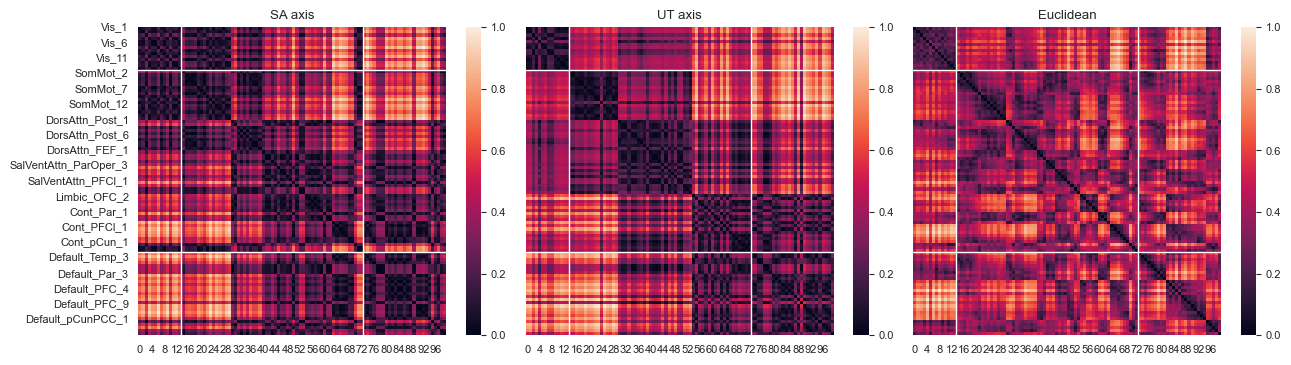

In [4]:
hidden_size = 100

# euclidean
centroids = pd.read_csv(eucl_kernel_file)
centroids = centroids[:hidden_size]  # pull out left hemisphere
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_','')
centroids.set_index("ROI Name", inplace=True)
distance_matrix = distance.pdist(centroids, "euclidean")  # get euclidean distances between nodes
distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix
distance_matrix_eucl = utils.normalize_x(distance_matrix)

# sa axis
sa_axis = np.load(sa_kernel_file)
sa_axis = sa_axis[:hidden_size]  # pull out left hemisphere
distance_matrix = utils.get_brainmap_distance(brain_map=sa_axis)
distance_matrix_sa = utils.normalize_x(distance_matrix)

# ut axis
ut_axis = np.load(ut_kernel_file)
ut_axis = ut_axis[:hidden_size]  # pull out left hemisphere
distance_matrix = utils.get_brainmap_distance(brain_map=ut_axis)
distance_matrix_ut = utils.normalize_x(distance_matrix)

# myelin
# myelin_data = np.load(myelin_data_file)
# myelin_data_df = pd.read_csv(myelin_data_df_file)
# myelin_axis = myelin_data[:hidden_size,myelin_data_df.myelin_available.to_numpy()].mean(axis=1)
# distance_matrix = utils.get_brainmap_distance(brain_map=myelin_axis)
# distance_matrix_myelin = utils.normalize_x(distance_matrix)

# n i/o
n_io = utils.get_n_io(mask_weights=True, hidden_size=hidden_size)
n_nodes_in = int(n_io.split('-')[0])
n_nodes_out = int(n_io.split('-')[1])
n_nodes_inter = hidden_size - n_nodes_in - n_nodes_out
n_nodes = n_nodes_in + n_nodes_inter + n_nodes_out

# node groups
node_groups = np.concatenate((np.ones((n_nodes_in,))*0, 
                              np.ones((n_nodes_inter,))*1, 
                              np.ones((n_nodes_out,))*2), 
                             axis=0)
node_groups_labels = ['in' if v == 0 else 'inter' if v==1 else 'out' for v in node_groups]

# node colors
col_input = np.array([228, 149, 145]) / 255 
col_bys = np.array([129, 223, 180]) / 255 
col_output = np.array([122, 139, 165]) / 255
colors = np.concatenate((np.tile(col_input, [n_nodes_in,1]), 
                         np.tile(col_bys, [n_nodes_inter,1]), 
                         np.tile(col_output, [n_nodes_out,1])), 
                        axis=0 ) 
colors_categ = np.unique(colors,axis=0)

# plot
plot_data = [
    ['SA axis', distance_matrix_sa],
    ['UT axis', distance_matrix_ut], 
    ['Euclidean', distance_matrix_eucl], 
    # ['Myelin', distance_matrix_myelin], 
]

fig, _ = plt.subplots(1, len(plot_data), figsize=(5*len(plot_data),4), squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)

for i in range(len(plot_data)):
    sns.heatmap(plot_data[i][1], ax=fig.axes[i], cbar=1)
    fig.axes[i].set_aspect('equal')
    fig.axes[i].set_title(plot_data[i][0])
    fig.axes[i].axhline(y=n_nodes_in, color='w', linewidth=1.)
    fig.axes[i].axvline(x=n_nodes_in, color='w', linewidth=1.)
    fig.axes[i].axhline(y=hidden_size-n_nodes_out, color='w', linewidth=1.)
    fig.axes[i].axvline(x=hidden_size-n_nodes_out, color='w', linewidth=1.)
    
# sns.heatmap(distance_matrix_sa, ax=fig.axes[0], cbar=1)
# fig.axes[0].set_aspect('equal')
# fig.axes[0].set_title('SA axis')
# fig.axes[0].axhline(y=n_nodes_in, color='w', linewidth=1.)
# fig.axes[0].axvline(x=n_nodes_in, color='w', linewidth=1.)
# fig.axes[0].axhline(y=hidden_size-n_nodes_out, color='w', linewidth=1.)
# fig.axes[0].axvline(x=hidden_size-n_nodes_out, color='w', linewidth=1.)

# sns.heatmap(distance_matrix_eucl, ax=fig.axes[1], cbar=1)
# fig.axes[1].set_aspect('equal')
# fig.axes[1].set_title('Euclidean')
# fig.axes[1].axhline(y=n_nodes_in, color='w', linewidth=1.)
# fig.axes[1].axvline(x=n_nodes_in, color='w', linewidth=1.)
# fig.axes[1].axhline(y=hidden_size-n_nodes_out, color='w', linewidth=1.)
# fig.axes[1].axvline(x=hidden_size-n_nodes_out, color='w', linewidth=1.)

# sns.heatmap(distance_matrix_ut, ax=fig.axes[2], cbar=1)
# fig.axes[2].set_aspect('equal')
# fig.axes[2].set_title('UT axis')
# fig.axes[2].axhline(y=n_nodes_in, color='w', linewidth=1.)
# fig.axes[2].axvline(x=n_nodes_in, color='w', linewidth=1.)
# fig.axes[2].axhline(y=hidden_size-n_nodes_out, color='w', linewidth=1.)
# fig.axes[2].axvline(x=hidden_size-n_nodes_out, color='w', linewidth=1.)

yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
fig.axes[0].set_yticklabels(roi_names[yticks], rotation=0, ha='right')
plt.show()

___
# fMRI analysis

## Load fMRI data

In [15]:
fmri_data_df = pd.read_csv(fmri_data_df_file)
fmri_data_df
use_fmri = pd.concat((fmri_data_df.rfMRI_available,
                      fmri_data_df.rfMRI_REST1_LR,
                      fmri_data_df.rfMRI_REST1_RL,
                      fmri_data_df.rfMRI_REST2_LR,
                      fmri_data_df.rfMRI_REST2_RL),
                     axis=1).to_numpy()
use_fmri = np.all(use_fmri,axis=1)
fmri_data = np.load(fmri_data_file)
fmri_ts = fmri_data[:,16:116,0,use_fmri]
n_fmri_subj = fmri_ts.shape[2]
n_fmri_steps = fmri_ts.shape[0]
print(f'fMRI time steps: {n_fmri_steps}')
print(f'fMRI N subjects: {n_fmri_subj}')

fMRI time steps: 1200
fMRI N subjects: 1086


## Compute fMRI AC, ACW, ACA

This section generates:

- `ac_data_fmri`: list of length `n_fmri_subj`
    - for each subject, the data is a dictionary
        - `ac`: an `(n_nodes, n_lags_rest)` array of AC vals
        - `acw_50`: an `(n_nodes,)` array of ACW_50 vals
        - `acw_0`: an `(n_nodes,)` array of ACW_0 vals
        - `aca_50`: an `(n_nodes,)` array of ACA_50 vals
        - `aca_0`: an `(n_nodes,)` array of ACA_0 vals

Here, `n_lags_rest` is user-defined.

In [16]:
ac_data_fmri = []
dynamic_keys = ['acw_50','acw_0','aca_50','aca_0']
n_lags_rest = 50

for subj in tqdm(range(n_fmri_subj), desc='Computing AC for fMRI'):
        
        # initialize arrays of AC, ACW, and ACA values for this subject
        ac_subj_rest = dict()
        ac_subj_rest['ac'] = np.zeros((n_nodes,n_lags_rest,))
        for k in dynamic_keys:
            ac_subj_rest[k] = np.zeros((n_nodes,))
        
        # nodes loop
        for node in range(n_nodes):
            
            # get values for rest
            ts = fmri_ts[:,node,subj]
            ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
            ac_subj_rest['ac'][node,:] = ac
            for k in dynamic_keys:
                ac_subj_rest[k][node] = globals()[k]
        
        # append this subject's data 
        ac_data_fmri.append(ac_subj_rest)

Computing AC for fMRI: 100%|██████████| 1086/1086 [00:06<00:00, 157.35it/s]


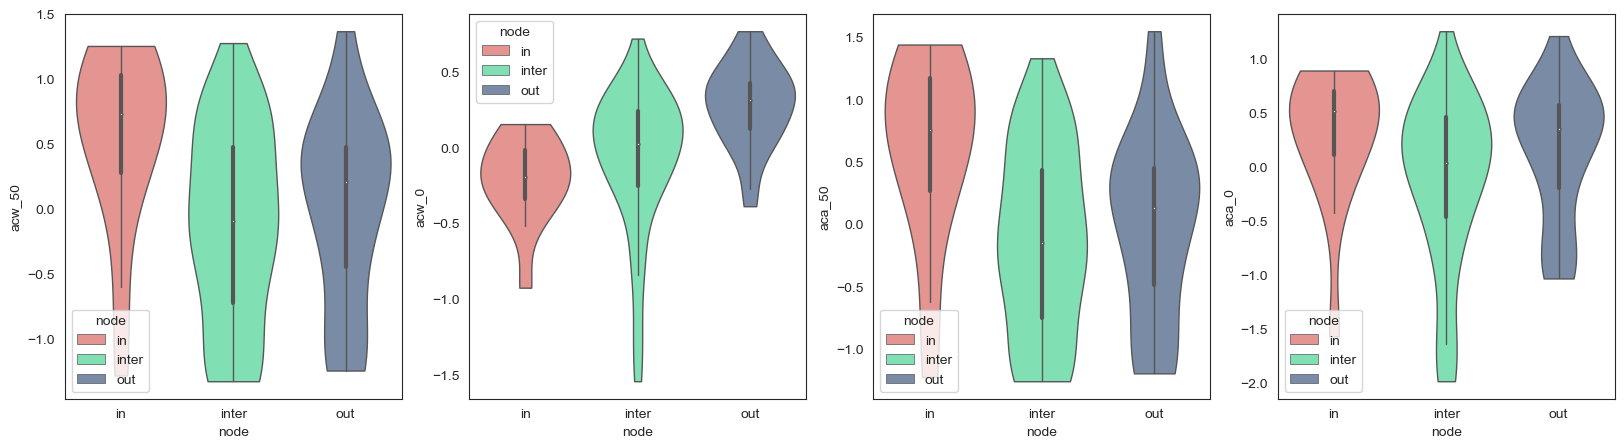

In [20]:
standardize = True   
subjmean = True  
fmri_ac_df = pd.DataFrame()
for subj in range(n_fmri_subj):
    subj_df = pd.DataFrame({
        'subj': subj,
        'acw_50': ac_data_fmri[subj]['acw_50'],
        'acw_0': ac_data_fmri[subj]['acw_0'],
        'aca_50': ac_data_fmri[subj]['aca_50'],
        'aca_0': ac_data_fmri[subj]['aca_0'],
        'node': node_groups_labels
    })
    if standardize:
        subj_df[dynamic_keys] = subj_df[dynamic_keys].apply(stats.zscore)
    if subjmean:
        if subj == 0:
            fmri_ac_df = subj_df
        else:
            fmri_ac_df[dynamic_keys] = fmri_ac_df[dynamic_keys] + subj_df[dynamic_keys]
    else:
        fmri_ac_df = pd.concat((fmri_ac_df,subj_df), ignore_index=True)
if subjmean:
    fmri_ac_df[dynamic_keys] = fmri_ac_df[dynamic_keys] / n_fmri_subj
f, ax = plt.subplots(figsize=(20,5), ncols=len(dynamic_keys), nrows=1, squeeze=True)
for i, k in enumerate(dynamic_keys):
    sns.violinplot(x='node', y=k, hue='node', data=fmri_ac_df, 
                linewidth=1, cut=0, saturation=1, inner='box', dodge=False,
                palette=np.flip(colors_categ,axis=0),
                ax=f.axes[i])

In [37]:
fmri_ac_df

,subj,acw_50,acw_0,aca_50,aca_0,node
0,0,-0.601972,-0.122895,-0.622835,-0.423471,in
1,0,0.756095,-0.187272,0.810043,0.484504,in
2,0,0.736325,0.125479,0.763079,0.600864,in
3,0,0.147480,-0.291499,0.129450,0.026399,in
4,0,1.227622,-0.233954,1.439400,0.765992,in
...,...,...,...,...,...,...
95,0,-0.259169,0.171410,-0.332666,-0.015810,out
96,0,0.633933,0.426161,0.561766,0.612679,out
97,0,-1.110717,-0.387944,-1.086679,-0.891251,out
98,0,0.210378,0.210741,0.128953,0.301044,out


## Plot fMRI AC, ACW, ACA

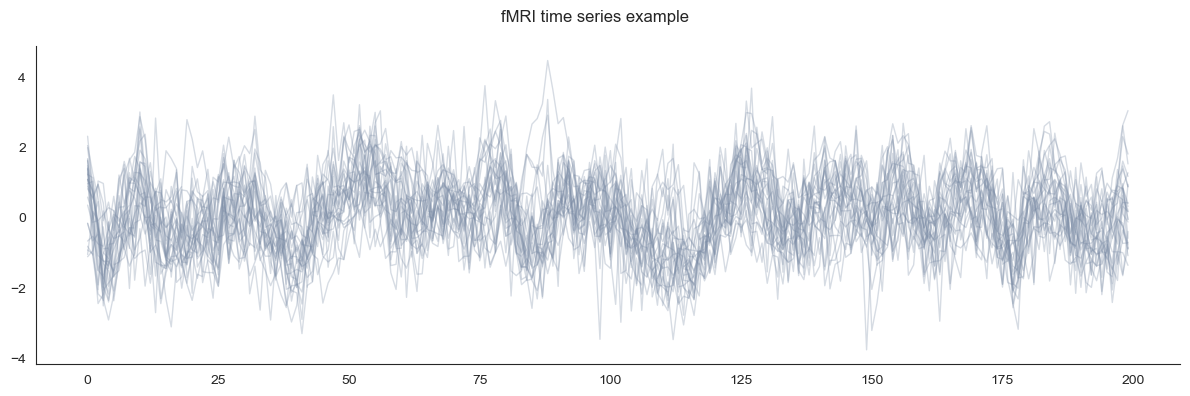

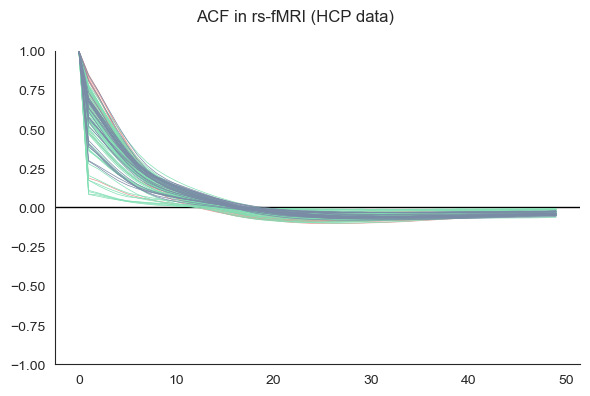

In [18]:
f, _ = plt.subplots(nrows=1,ncols=1,figsize=(12,4),squeeze=True)
for node in range(n_nodes):
    if node_groups[node] == 2:
        plt.plot(fmri_ts[:200,node,0], color=colors[node,:], linewidth=1, alpha=0.3)
f.suptitle('fMRI time series example')
sns.despine(fig=f, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
f.tight_layout()
plt.show()


# initialize figure
f, _ = plt.subplots(nrows=1, ncols=1, figsize=(6,4), squeeze=True)

# add a y=0 line for reference
f.axes[0].axhline(y=0, color='k', linewidth=1.)

# initialize ac vals array
y_plot = np.zeros((n_nodes,n_lags_rest,n_fmri_subj)) 

# get data from each subject
for subj in range(n_fmri_subj):
    y_plot[:,:,subj] = ac_data_fmri[subj]['ac']

# calculate mean acros subjects
y_plot = np.squeeze(y_plot.mean(axis=2))

# plot
for node in range(n_nodes):
    plt.plot(y_plot[node,:], color=colors[node,:], linewidth=0.5, alpha=1)

# polish plots
f.axes[0].set_ylim((-1,1))
f.suptitle('ACF in rs-fMRI (HCP data)')
sns.despine(fig=f, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
f.tight_layout()
plt.show()


___
# Eigenvalue analysis

## Define calculation and plotting functions

In [94]:
# Extract and order eigenvalues by their magnitude (norm), then select the first three
def extract_mean_and_ci_real_eigenvalues(w_epochs):
    mean_real_parts_per_epoch = []  # To store mean real parts of eigenvalues for each epoch
    ci_real_parts_per_epoch = []   # To store confidence intervals for each epoch

    for epoch_weights in w_epochs:
        # Each epoch_weights is a list of weight matrices for different runs
        epoch_real_parts = []
        for W in epoch_weights:
            # Compute eigenvalues and order by their magnitude
            eigenvalues = np.linalg.eig(W)[0]
            sorted_eigenvalues = sorted(eigenvalues, key=lambda x: abs(x), reverse=True)  # Sort by magnitude
            # Select the first 3 eigenvalues and extract the real parts
            epoch_real_parts.append([ev.real for ev in sorted_eigenvalues[:3]])  # First 3 real parts
        
        # Compute mean and 95% CI across runs for each eigenvalue
        epoch_real_parts = np.array(epoch_real_parts)  # Shape: (n_runs, 3)
        mean_real_parts = np.mean(epoch_real_parts, axis=0)
        ci_real_parts = 1.96 * np.std(epoch_real_parts, axis=0) / np.sqrt(epoch_real_parts.shape[0])  # 95% CI 
        
        mean_real_parts_per_epoch.append(mean_real_parts)
        ci_real_parts_per_epoch.append(ci_real_parts)
    
    return np.array(mean_real_parts_per_epoch), np.array(ci_real_parts_per_epoch)

# Plot the mean real part trajectories with 95% CI shader
def plot_mean_real_eigenvalue_trajectories_with_ci(mean_real_parts_per_epoch, ci_real_parts_per_epoch, ax, task_label, kernel_label):
    n_epochs = mean_real_parts_per_epoch.shape[0]

    ax.set_title(f"{task_label} [{kernel_label}]")
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)
    ax.axhline(color='black',linewidth=1)

    colors = ['red', 'blue', 'green']  # Colors for the first three eigenvalues
    for i, color in enumerate(colors):  # i corresponds to eigenvalue index
        mean_trajectory = mean_real_parts_per_epoch[:, i]
        ci_trajectory = ci_real_parts_per_epoch[:, i]
        
        # Plot the mean line
        ax.plot(range(n_epochs), mean_trajectory, color=color, linestyle='-', alpha=0.8, label=f"Eigenvalue {i + 1}")
        
        # Add the confidence interval as a shaded region
        ax.fill_between(range(n_epochs), 
                        mean_trajectory - ci_trajectory, 
                        mean_trajectory + ci_trajectory, 
                        color=color, alpha=0.2)

    # Add legend
    ax.legend(loc="upper right", fontsize="small")


## Load model states

In [95]:
w_models = []
for model_idx in tqdm(range(n_models), desc='Loading models'):
        
        # get model details
        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        # get data file name
        file_path = os.path.join(modeldir, this.file_str_models)
        
        # remove delay variability for testing
        if 'delay' in this['env_kwargs']['timing']:
            d, _ = utils.parse_task_modifier(this.task_modifier)
            this['env_kwargs']['timing']['delay'] = d[0]

        # get info
        state_manager = ModelStateManager(file_path)
        n_runs, logged_epochs, keys_per_epoch = state_manager.get_info()
        n_runs = np.min((n_runs,100))
        
        # load hh weights for each logged epoch
        w_epochs = [] # list where each item holds the model state from one logged epoch
        for epoch in logged_epochs:
            whh = state_manager.load_key_across_runs(epoch=epoch, key='rnn.weight_hh_l0')
            w_epochs.append(whh)
        
        # append this model's data
        w_models.append(w_epochs)
        

Loading models: 100%|██████████| 3/3 [00:02<00:00,  1.03it/s]


## Get eigenvalues

In [96]:
# get eigenvalues
eigenvalues = []
eigenvalues_ci = []
for model_idx in tqdm(range(n_models), desc='Calculating eigenvalues'):
    w_epochs = w_models[model_idx]
    mean_real_parts_per_epoch, ci_real_parts_per_epoch = extract_mean_and_ci_real_eigenvalues(w_epochs)
    eigenvalues.append(mean_real_parts_per_epoch)
    eigenvalues_ci.append(ci_real_parts_per_epoch)

Calculating eigenvalues: 100%|██████████| 3/3 [00:15<00:00,  5.19s/it]


## Plot eigenvalues

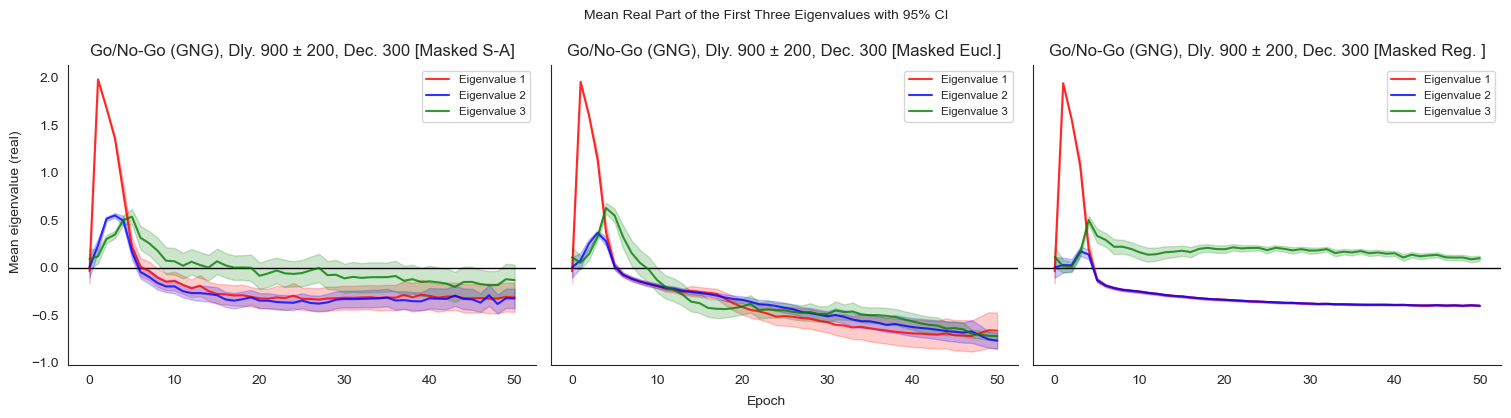

In [97]:
# plot eigenvalues
size_scale = 2
font_size = int(5 * size_scale)
n_fig_columns = min((3, n_models))
n_fig_rows = math.ceil( n_models / n_fig_columns )
fig_size_w = 2.5*n_fig_columns*size_scale
fig_size_h = 2*n_fig_rows*size_scale
fig, ax = plt.subplots(ncols=n_fig_columns, nrows=n_fig_rows, 
                       figsize=(fig_size_w,fig_size_h), squeeze=True, sharey=True)

for model_idx in range(n_models):
    plot_mean_real_eigenvalue_trajectories_with_ci(eigenvalues[model_idx], 
                                                   eigenvalues_ci[model_idx], 
                                                   fig.axes[model_idx], 
                                                   model_params.task_label[model_idx],
                                                   model_params.kernel_label[model_idx])

sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
fig.suptitle("Mean Real Part of the First Three Eigenvalues with 95% CI", fontsize=font_size)
fig.text(0.5, 0.0, 'Epoch', ha='center', va='center', rotation='horizontal', fontsize=font_size)
fig.text(0.0, 0.5, 'Mean eigenvalue (real)', ha='center', va='center', rotation='vertical', fontsize=font_size)
fig.tight_layout()
plt.show()


___
# Load trained models

This section generates:
- `trained_models_all`: list of length `n_models`
    - for each model, the data is a list of length `n_runs`
        - for each run, the data is a dictionary
            - `dataset`: the neurogym dataset with which the model can be tested
            - `rnn`: the test-ready rnn

In [98]:
device = torch.device('cpu')

if check_only:
    
    found_count = 0
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        file_path = os.path.join(modeldir, this.file_str_models)
        file_exists = os.path.isfile(file_path)
        if file_exists:
            found_count += 1
        else:
            print(f'Not found ... {this.file_str} ({model_idx})')
    print(f'Found {found_count}/{n_models} files.')
    
else:
    
    trained_models_all = [] # list where each item holds the model states from one model
    
    for model_idx in tqdm(range(n_models), desc='Loading data'):
        
        # get model details
        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        # get data file name
        file_path = os.path.join(modeldir, this.file_str_models)
        
        # remove delay variability for testing
        if 'delay' in this['env_kwargs']['timing']:
            d, _ = utils.parse_task_modifier(this.task_modifier)
            this['env_kwargs']['timing']['delay'] = d[0]

        # try:
        # get info
        state_manager = ModelStateManager(file_path)
        n_runs, logged_epochs, keys_per_epoch = state_manager.get_info()
        n_runs = np.min((n_runs,100))
        # create rnn and dataset for each trained run
        trained_models = [] # list where each item holds the model states from one run 
        for run in range(n_runs):
            dataset, rnn = create_rnn_and_env_for_model(this, 
                                                        run = run, 
                                                        epoch = logged_epochs[-1], 
                                                        data_dir = modeldir, 
                                                        device = device)
            trained_models.append({'dataset': dataset, 'rnn': rnn})
        trained_models_all.append(trained_models)
        # except:
        #     print("An error occurred:", sys.exc_info()[0])
        #     print("Exception message:", sys.exc_info()[1])

Loading data: 100%|██████████| 3/3 [00:04<00:00,  1.64s/it]


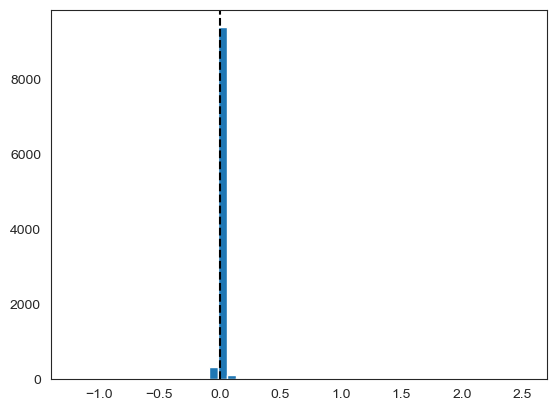

In [99]:
m = 0
dataset, rnn = create_rnn_and_env_for_model(model_params.iloc[m], 
                                            run = 20, 
                                            epoch = 4999, 
                                            data_dir = modeldir, 
                                            device = device)
s = rnn.state_dict()
plt.figure()
plt.axvline(linestyle='--',color='black')
plt.hist(s['rnn.weight_hh_l0'].view(-1),bins=50)
plt.show()

___
# Test models

This section generates:
- `testing_data_all`: list of length `n_models`
    - for each model, the data is a list of length `n_runs`
        - for each run, the data is a dictionary
            - `accuracy`: scalar representing the mean accuracy over all test trials
            - `inputs`: list of length `n_trials`
                - for each trial, the data is a `(n_steps, n_input_channels)` array of RNN inputs
            - `labels`: list of length `n_trials`
                - for each trial, the data is a `(n_steps,)` array of ground truth outputs
            - `hidden_activity`: list of length `n_trials`
                - for each trial, the data is a `(n_steps, n_nodes)` array of the RNN's hidden layer activity
            - `output_activity`: list of length `n_trials`
                - for each trial, the data is a `(n_steps, n_output_channels)` array of the RNN's output layer activity
            - `info`: dataframe with `n_trials` rows and 3 columns containing summary info about each trial 
- `testing_data_rest_all`: list of length `n_models`
    - for each model, the data is a list of length `n_runs`
        - for each run, the data is a dictionary
            - `inputs`: `(n_rest_steps, n_input_channels)` array of RNN inputs
            - `hidden_activity`: `(n_rest_steps, n_nodes)` array of the RNN's hidden layer activity
            - `output_activity`: `(n_rest_steps, n_output_channels)` array of the RNN's output layer activity

Here:
- `n_trials` is user-defined.
- `n_rest_steps = n_trial_steps * n_trials`
- `n_trial_steps` is the length of a single trial used during model training

In [49]:
# define number of test trials
n_trials = 100

# define window size for smoothing of noise input during resting state testing
smooth_noise = 0

# initialize output lists where each item is data from one model
test_data_task = []
test_data_rest = []

# models loop
for model_idx in tqdm(range(n_models), desc='Testing models'):
    
    # get all trained runs of this model
    trained_models = trained_models_all[model_idx]
    
    # initialize model output lists where each item is data from one run
    test_model_task = []
    test_model_rest = []
    
    # runs loop
    for run in range(len(trained_models)):
        
        # get this run's ngym dataset
        dataset = trained_models[run]['dataset']
        
        # get this run's trained model
        rnn = trained_models[run]['rnn']
        
        # test this run on unseen task trials
        accuracy, inputs, labels, hidden_activity, output_activity, info \
            = run_testing(dataset=dataset,
                          model=rnn,
                          n_trials=n_trials,
                          verbose=False)
        this_test_task = {
            'accuracy': accuracy,
            'inputs': inputs,
            'labels': labels,
            'hidden_activity': hidden_activity,
            'output_activity': output_activity,
            'info': info
        }
        test_model_task.append(this_test_task)
        
        # # create noise inputs for resting state testing
        # n_rest_steps = int( sum(model_params.iloc[0]['env_kwargs']['timing'].values()) / model_params.iloc[0]['time_step'] ) * n_trials
        
        # test this run on noise inputs
        inputs_rest, hidden_activity_rest, output_activity_rest = run_testing_rest(rnn, smooth_noise=smooth_noise)
        this_test_rest = {
            'inputs': inputs_rest,
            'hidden_activity': hidden_activity_rest,
            'output_activity': output_activity_rest
        }
        test_model_rest.append(this_test_rest)
    
    # append this model's data (all runs)
    test_data_task.append(test_model_task)
    test_data_rest.append(test_model_rest)

Testing models: 100%|██████████| 3/3 [00:10<00:00,  3.58s/it]


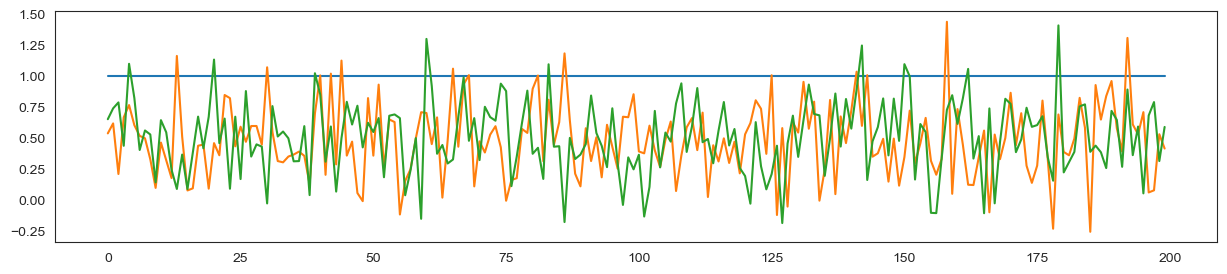

In [50]:
plt.figure(figsize=(15,3))
plt.plot(inputs_rest[:200,:])
plt.show()

___
# Intrinsic neural timescales

The goal is to generate brain maps of intrinsic neural timescales (INTs) based on some quantification of the decay in the autocorrelation of node time series. Ahmad to look into ways to quantify the ACF function. Then we can examine spatial correlations (pearson, spearman) between RNN-based INTs as well as between RNN INTs and empirical INTs.

## Compute AC, ACW, and ACA

This section generates:
- `ac_data_task`: list of length `n_models`
    - for each model, the data is a list of length `n_runs`
        - for each run, the data is a dictionary
            - `ac`: an `(n_nodes, n_lags_task, n_trials)` array of AC vals
            - `acw_50`: an `(n_nodes, n_trials)` array of ACW_50 vals
            - `acw_0`: an `(n_nodes, n_trials)` array of ACW_0 vals
            - `aca_50`: an `(n_nodes, n_trials)` array of ACA_50 vals
            - `aca_0`: an `(n_nodes, n_trials)` array of ACA_0 vals
- `ac_data_rest`: list of length `n_models`
    - for each model, the data is a list of length `n_runs`
        - for each run, the data is a dictionary
            - `ac`: an `(n_nodes, n_lags_rest)` array of AC vals
            - `acw_50`: an `(n_nodes,)` array of ACW_50 vals
            - `acw_0`: an `(n_nodes,)` array of ACW_0 vals
            - `aca_50`: an `(n_nodes,)` array of ACA_50 vals
            - `aca_0`: an `(n_nodes,)` array of ACA_0 vals

Here:
- `n_lags_task = n_time_trial - 1`
- `n_lags_rest` is user-defined

In [51]:
# initialize lists that will store model-wise data
ac_data_task = []
ac_data_rest = []
dynamic_keys = ['acw_50','acw_0','aca_50','aca_0']

# models loop
for model_idx in tqdm(range(n_models), desc='Calculating AC'):
    
    # initialize lists that will store run-wise data
    ac_model_task = []
    ac_model_rest = []
    
    # calculate data dimensions
    n_runs = len(test_data_task[model_idx])
    n_nodes = test_data_task[model_idx][0]['hidden_activity'][0].shape[1]
    n_time_task = test_data_task[model_idx][0]['hidden_activity'][0].shape[0]
    n_lags_task = n_time_task-1
    n_lags_rest = 50
    
    # runs loop
    for run in range(n_runs):
        
        # initialize arrays of AC, ACW, and ACA values for this run
        ac_run_task = dict()
        ac_run_task['ac'] = np.zeros((n_nodes,n_lags_task,n_trials))
        for k in dynamic_keys:
            ac_run_task[k] = np.zeros((n_nodes,n_trials))
        
        ac_run_rest = dict()
        ac_run_rest['ac'] = np.zeros((n_nodes,n_lags_rest,))
        for k in dynamic_keys:
            ac_run_rest[k] = np.zeros((n_nodes,))
        
        # nodes loop
        for node in range(n_nodes):
            
            # get values for task trials
            for trial in range(n_trials):
                ts = test_data_task[model_idx][run]['hidden_activity'][trial][:,node]
                ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_task)
                ac_run_task['ac'][node,:,trial] = ac
                for k in dynamic_keys:
                    ac_run_task[k][node,trial] = globals()[k]
            
            # get values for rest
            ts = test_data_rest[model_idx][run]['hidden_activity'][:,node]
            ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
            ac_run_rest['ac'][node,:] = ac
            for k in dynamic_keys:
                ac_run_rest[k][node] = globals()[k]
        
        # append this run's data to this model's list
        ac_model_task.append(ac_run_task)
        ac_model_rest.append(ac_run_rest)
    
    # append this model's list to the model-wise list
    ac_data_task.append(ac_model_task)
    ac_data_rest.append(ac_model_rest)
    

Calculating AC: 100%|██████████| 3/3 [00:31<00:00, 10.55s/it]


40
49
34
45
37
37
36
37
30
42
36
49
34
35
44
38
44
39
33
35
42
44
40
37
38
40
37
38
45
30
42
37
37
30
35
38
43
41
41
42
35
32
42
43
39
35
43
41
42
36


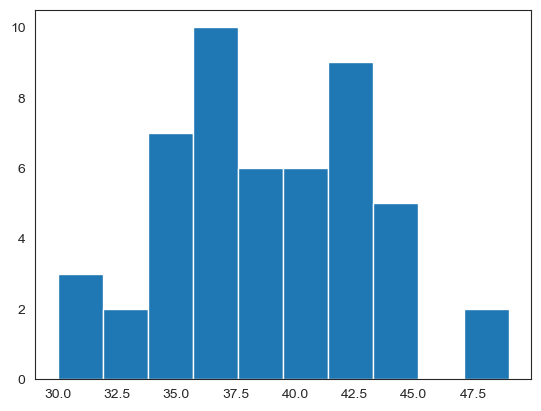

In [52]:
m = 0
r = 0
t = 0
c = []
for r in range(50): # runs 
    n = []
    for i in range(100): # nodes 
        if np.all(np.isnan(ac_data_task[m][r]['ac'][i,:,:])):
            n.append(i)
    # print(n)
    print(len(n))
    c.append(len(n))
# x = test_data_task[m][r]['hidden_activity'][t][:,n]
# plt.figure()
# plt.plot(x)
# plt.show()
plt.figure()
plt.hist(c)
plt.show()

[1, 4, 6, 10, 15, 16, 18, 20, 25, 26, 27, 28, 29, 31, 34, 37, 38, 40, 47, 48, 56, 62, 65, 66, 68, 72, 73, 76, 78, 80, 81, 82, 87, 93, 95, 96, 98, 99]
38


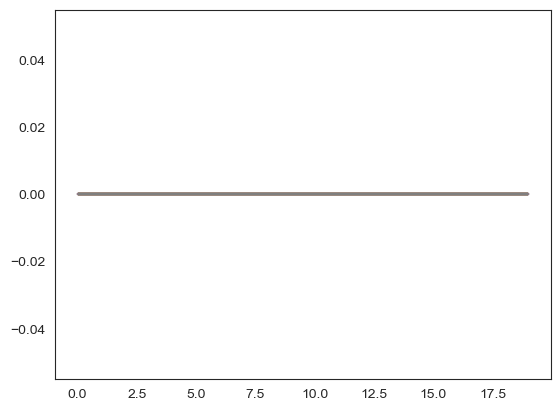

In [53]:
m = 0
r = 0
n = []
for i in range(100):
    if np.all(np.isnan(ac_data_rest[0][0]['ac'][i,:])):
        n.append(i)
print(n)
print(len(n))
x = test_data_task[m][r]['hidden_activity'][t][:,n]
plt.figure()
plt.plot(x)
plt.show()

## Plot results.

### Activity

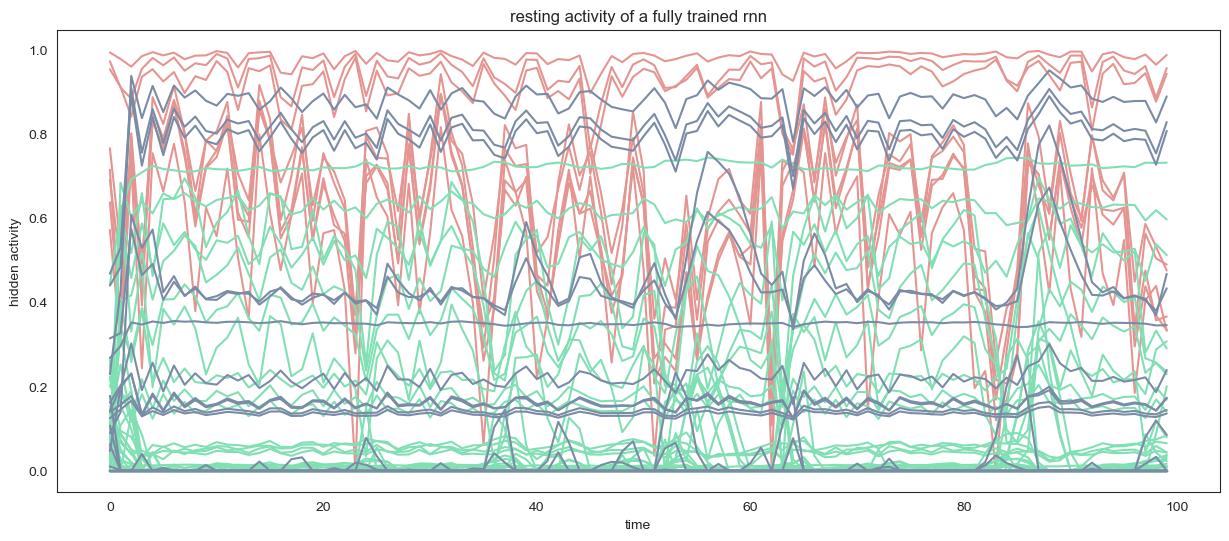

In [140]:
m = 0
r = 0
dataset, rnn = create_rnn_and_env_for_model(model_info=model_params.iloc[0], 
                                            run=r, 
                                            epoch=4999, 
                                            data_dir=modeldir, 
                                            device=device)
inputs_rest, hidden_activity_rest, output_activity_rest = run_testing_rest(rnn, smooth_noise=0)
plt.figure(figsize=(15,6))
for n in range(n_nodes):
    plt.plot(hidden_activity_rest[:100,n], color=colors[n,:])
    plt.xlabel('time')
    plt.ylabel('hidden activity')
    plt.title('resting activity of a fully trained rnn')
plt.show()


In [104]:
hidden_activity_rest.shape

(1000, 100)

### Hidden weights.

In [ ]:
# figure params
size_scale = 2
font_size = int(5 * size_scale)
n_fig_columns = n_tasks
n_fig_rows = n_kernels
fig_size_w = 2.5*n_fig_columns*size_scale
fig_size_h = 2*n_fig_rows*size_scale

# create subplots
fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                        squeeze=True, sharex=True, sharey=True)
plt.rcParams['font.size'] = font_size

# begin plotting loop
for model_idx in range(n_models):
    for run in range(n_runs):
        rnn = trained_models_all[model_idx][run]['rnn']
        if run == 0:
            weights = rnn.state_dict()['rnn.weight_hh_l0']
        else:
            weights = weights + rnn.state_dict()['rnn.weight_hh_l0']
    weights = weights / n_runs
    
    # plot
    sns.heatmap(weights, ax=fig.axes[model_idx], cbar=1)
    fig.axes[model_idx].set_aspect('equal')
    fig.axes[model_idx].set_title(f"{model_params.loc[model_idx,'task_label']}\n{model_params.loc[model_idx,'kernel_label']}")
    fig.axes[model_idx].axhline(y=n_nodes_in, color='w', linewidth=1.)
    fig.axes[model_idx].axvline(x=n_nodes_in, color='w', linewidth=1.)
    fig.axes[model_idx].axhline(y=hidden_size-n_nodes_out, color='w', linewidth=1.)
    fig.axes[model_idx].axvline(x=hidden_size-n_nodes_out, color='w', linewidth=1.)




### AC vs. lag plots.

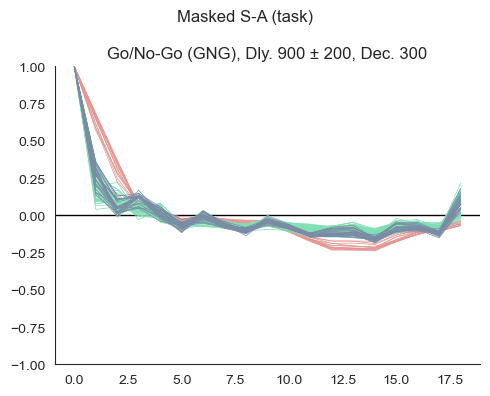

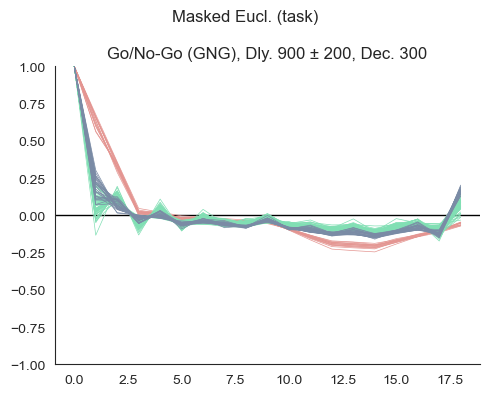

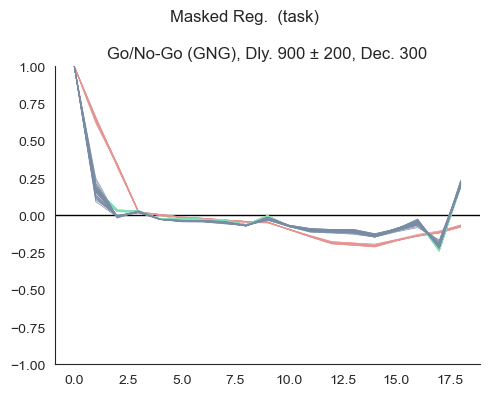

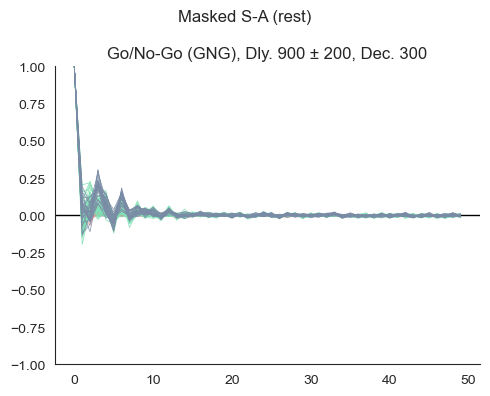

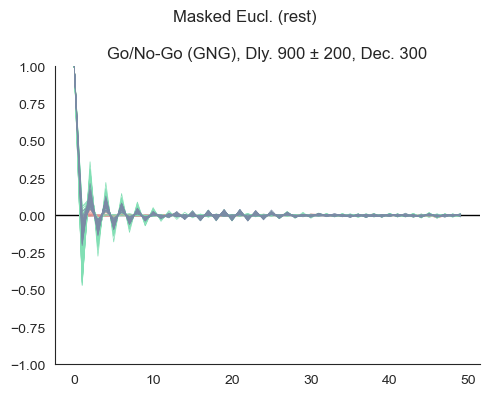

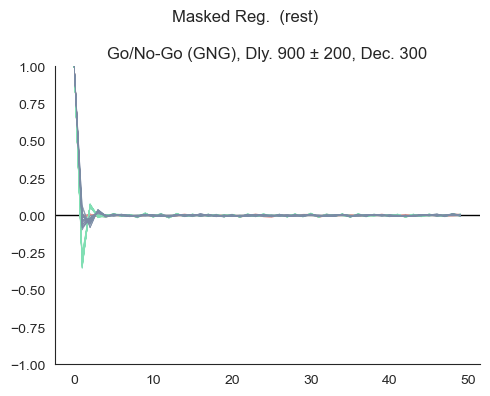

In [54]:
# figure params
size_scale = 2
font_size = int(5 * size_scale)
n_fig_columns = min((3, n_tasks))
n_fig_rows = math.ceil( n_tasks / n_fig_columns )
fig_size_w = 2.5*n_fig_columns*size_scale
fig_size_h = 2*n_fig_rows*size_scale

plotting_data = [
    [ac_data_task, 'task'],
    [ac_data_rest, 'rest']
]

# begin plotting loop
for i in range(len(plotting_data)):

    # for the full AC plots, we will create one subplot per task/kernel combination
    for kernel_idx in range(n_kernels):
        
        # create subplots
        f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                               squeeze=True, sharex=True, sharey=True)
        plt.rcParams['font.size'] = font_size
        
        # models loop
        for model_idx in range(n_models):
            if model_params.loc[model_idx, 'kernel_index'] == kernel_idx:
                task_index = model_params.loc[model_idx, 'task_index']
                
                # add a y=0 line for reference
                f_ac.axes[task_index].axhline(y=0, color='k', linewidth=1.)
                
                # initialize the y-data matrix
                this_data = plotting_data[i][0]
                n_lags = this_data[model_idx][0]['ac'].shape[1]
                y_plot = np.zeros((n_nodes,n_lags,n_runs)) 
                
                # populate matrix with mean across trials for each node and each run
                for run in range(n_runs):
                    run_data = this_data[model_idx][run]['ac']
                    if run_data.ndim == 3:
                        y_plot[:,:,run] = np.nanmean(run_data, axis=2)
                    else:
                        y_plot[:,:,run] = run_data
                
                # calculate mean across runs
                y_plot = np.squeeze(np.nanmean(y_plot, axis=2))
                
                # plot
                for node in range(n_nodes):
                    f_ac.axes[task_index].plot(y_plot[node,:], color=colors[node,:], linewidth=0.5, alpha=1)
                f_ac.axes[task_index].set_title(model_params.loc[model_idx,'task_label'])

        # polish plots
        f_ac.axes[0].set_ylim((-1,1))
        f_ac.suptitle(kernel_labels[kernel_idx] + ' (' + plotting_data[i][1] + ')')
        sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
        f_ac.tight_layout()
        plt.show()

### ACW and ACA violin plots.

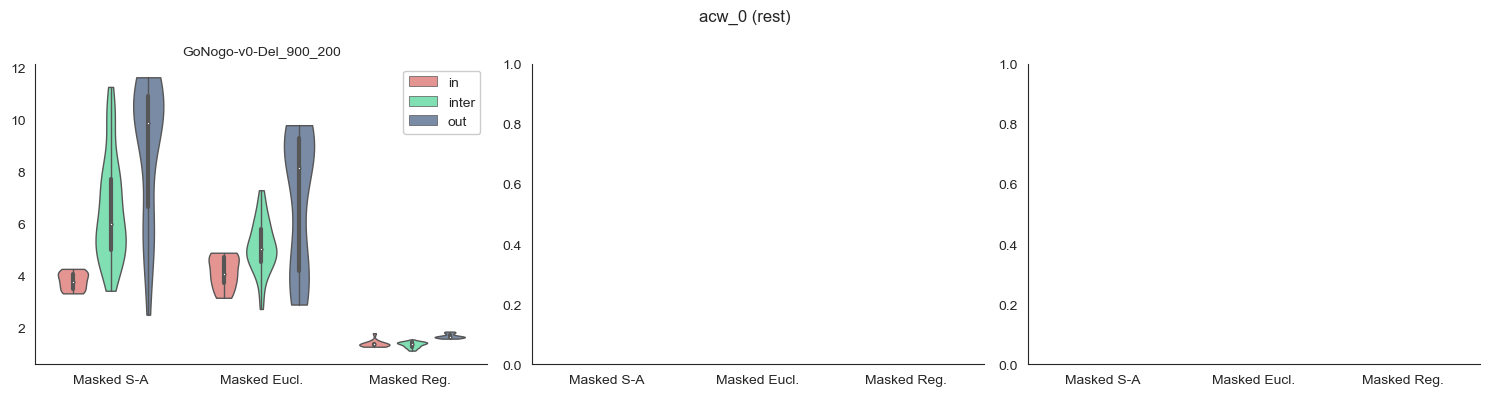

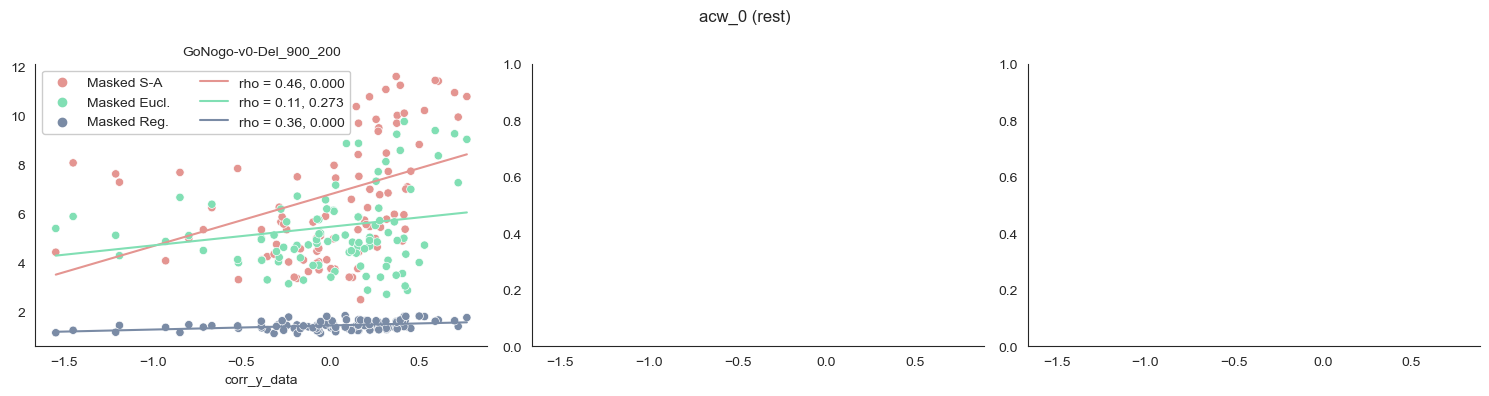

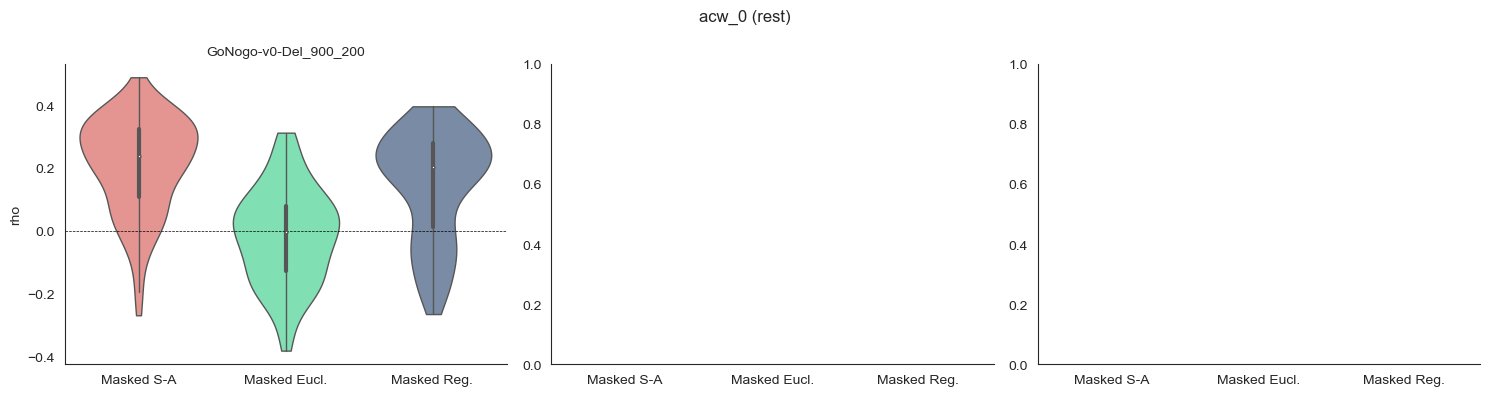

In [51]:
# re-organize data for easier handling
plotting_data = [
    # [ac_data_task, 'task'],
    [ac_data_rest, 'rest']
]
plotting_keys = [
    # 'acw_50',
    'acw_0',
    # 'aca_50',
    # 'aca_0'
]
ac_data_task_dfs = dict()
ac_data_rest_dfs = dict()

# figure params
size_scale = 2
font_size = int(5 * size_scale)
n_fig_columns = min((5, n_tasks))
n_fig_rows = math.ceil( n_tasks / n_fig_columns )
fig_size_w = 2.5*n_fig_columns*size_scale
fig_size_h = 2*n_fig_rows*size_scale

# we will create separate figures for task data and rest data,
# and for each of acw_50, acw_0, aca_50, aca_0
for i in range(len(plotting_data)):
    
    for j in range(len(plotting_keys)):

        # for the ACW and ACA plots, we will create one subplot per task
        # each subplot will contain three violins for each kernel, where the 
        # colors are based on the node group
        
        # create subplots
        f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                               squeeze=True, sharex=True, sharey=False)
        f_scat, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                                 squeeze=True, sharex=True, sharey=False)
        f_corr, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                                 squeeze=True, sharex=True, sharey=False)
        plt.rcParams.update({
            'font.size': font_size,
            'axes.labelsize': font_size,
            'axes.titlesize': font_size,
            'xtick.labelsize': font_size,
            'ytick.labelsize': font_size,
            'legend.fontsize': font_size,
            'figure.titlesize': font_size+2
        })

        
        # tasks loop
        for task_index in [0]: # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< range(n_tasks):
            
            # get data for this task
            this_task_models = model_params[model_params['task_index']==task_index] # df of selected models
            
            # initialize dataframe for plots and for corr
            plotting_df = pd.DataFrame()
            corr_df = pd.DataFrame()
            corr_violins_df = pd.DataFrame()
            
            for model_idx in range(len(this_task_models)):
                
                # get data for this model
                this_model_data = plotting_data[i][0][this_task_models.iloc[model_idx].model_index] # list of runs
                this_model_kernel = this_task_models.iloc[model_idx].kernel_label
                this_model_task = this_task_models.iloc[model_idx].task_label
                
                # initialize y values array
                y_plot = np.zeros((n_nodes,len(this_model_data))) 
                
                # populate array with mean across trials for each node and each run
                for run in range(n_runs):
                    run_data = this_model_data[run][plotting_keys[j]]
                    if run_data.ndim == 2:
                        y_plot[:,run] = run_data.mean(axis=1) # mean across task trials 
                    else:
                        y_plot[:,run] = run_data # values from rest 
                
                # calculate mean across runs
                y_plot_all_runs = y_plot
                y_plot = np.squeeze(y_plot.mean(axis=1))
                
                # select nodes to correlate
                # corr_nodes = node_groups==1
                corr_nodes = np.ones(node_groups.shape).astype(bool)
                
                # calcualte corr and regression for mean vals
                corr_y_data = fmri_ac_df[plotting_keys[j]].to_numpy()
                # corr_y_data = sa_axis
                slope, intercept, r_value, p_value, std_err = stats.linregress(corr_y_data[corr_nodes], y_plot[corr_nodes])
                spearman_r, spearman_p = stats.spearmanr(corr_y_data[corr_nodes], y_plot[corr_nodes])
                line_x = np.array([min(corr_y_data[corr_nodes]), max(corr_y_data[corr_nodes])])
                line_y = slope * line_x + intercept
                
                # calculate corr for each run and add to df
                for run in range(n_runs):
                    spearman_r_run, spearman_p_run = stats.spearmanr(corr_y_data[corr_nodes], y_plot_all_runs[corr_nodes,run])
                    this_corr_violin_df = pd.DataFrame({'r': spearman_r_run,
                                                        'p': spearman_p_run,
                                                        'run': run,
                                                        'task': this_model_task,
                                                        'kernel': this_model_kernel
                                                        }, index=[0])
                    corr_violins_df = pd.concat([corr_violins_df, this_corr_violin_df], ignore_index=True)
                
                # add this model's data to the plotting df
                this_plotting_df = pd.DataFrame({'y': y_plot, 
                                                 'task': this_model_task, 
                                                 'kernel': np.repeat(this_model_kernel,(n_nodes)), 
                                                 'node_group': node_groups_labels,
                                                 'corr_y_data': corr_y_data
                                                 })
                plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)
                
                # add this model's data to the corr df
                this_corr_df = pd.DataFrame({'slope': slope, 
                                             'intercept': intercept, 
                                             'r': r_value, 
                                             'p': p_value, 
                                             'line_x': [line_x],
                                             'line_y': [line_y], 
                                             'std_err': std_err,
                                             'spearman_r': spearman_r,
                                             'spearman_p': spearman_p, 
                                             'task': this_model_task,
                                             'kernel': this_model_kernel
                                             })
                corr_df = pd.concat([corr_df, this_corr_df], ignore_index=True)
            
            
            # --------------------------------------
            # create scatter plots of mean corr
            # --------------------------------------
            
            # create color palette
            palette = dict(zip(plotting_df.kernel.unique(),np.flip(colors_categ,axis=0)))
            
            # plot
            ax = f_scat.axes[task_index]
            sns.scatterplot(data=plotting_df, x='corr_y_data', y='y', hue='kernel',
                            palette=palette,
                            ax=f_scat.axes[task_index])
            
            for k in range(len(corr_df)):
                reg_line_data = corr_df.iloc[k]
                ax.plot(reg_line_data.line_x, reg_line_data.line_y, color=np.flip(colors_categ,axis=0)[k,:], linestyle='-', label=f'rho = {reg_line_data.spearman_r:.2f}, {reg_line_data.spearman_p:.3f}')
            
            # polish plots
            ax.set_ylabel('')
            ax.legend(ncol=2, framealpha=1.0)
            ax.set_title(task_names[task_index])
            f_scat.suptitle(plotting_keys[j] + ' (' + plotting_data[i][1] + ')')
            sns.despine(fig=f_scat, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_scat.tight_layout()
            
            # --------------------------------------
            # create violin plots of corr vals
            # --------------------------------------
            
            # plot
            ax = f_corr.axes[task_index]
            sns.violinplot( x='kernel', y='r', data=corr_violins_df,
                            linewidth=1, cut=0, saturation=1, inner='box', dodge=False, 
                            palette=palette, 
                            ax=ax)
            # polish plots
            ax.set_xlabel('')
            ax.set_ylabel('rho')
            ax.set_title(task_names[task_index])
            f_corr.suptitle(plotting_keys[j] + ' (' + plotting_data[i][1] + ')')
            sns.despine(fig=f_corr, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_corr.tight_layout()
            ax.axhline(y=0, color='k', linewidth=0.5, linestyle='--')
            
            # --------------------------------------
            # create violin plots of ac vals
            # --------------------------------------
                
            # add padding between kernels in df
            plotting_df['x_labels'] = plotting_df['kernel'] + ' -- ' + plotting_df['node_group']
            kernels = plotting_df.kernel.unique()
            plotting_df_with_space = pd.DataFrame()
            # violin_order = []
            for ki, k in enumerate(kernels):
                plotting_df_with_space = pd.concat([
                    plotting_df_with_space, 
                    plotting_df[plotting_df['kernel'] == k]
                ])
                # violin_order.append(k)
                if ki < len(kernels)-1:
                    plotting_df_with_space = pd.concat([
                        plotting_df_with_space, 
                        pd.DataFrame({'x_labels': [''], 'y': [None]})
                    ])
                    # violin_order.append('')
            plotting_df = plotting_df_with_space
            
            # get plotting order 
            mask = (plotting_df['x_labels'] != plotting_df['x_labels'].shift())
            violin_order = plotting_df.loc[mask, 'x_labels']
            # violin_order = [v if isinstance(v,str) else '' for v in plotting_df.loc[mask, 'kernel'].tolist()]
            hue_order = plotting_df.node_group.unique()[:-1].astype(str)
            palette = dict(zip(hue_order,np.flip(colors_categ,axis=0)))
            
            # plot
            plot_type = 'violin' # violin or swarm
            if plot_type == 'violin':
                sns.violinplot(x='x_labels', y='y', hue='node_group', data=plotting_df,
                            linewidth=1, cut=0, saturation=1, inner='box', dodge=False, 
                            palette=palette, order=violin_order, hue_order=hue_order,
                            ax=f_ac.axes[task_index])
            elif plot_type == 'swarm':
                sns.swarmplot(x='x_labels', y='y', hue='node_group', data=plotting_df,
                            linewidth=1, dodge=False, 
                            palette=palette, order=violin_order, hue_order=hue_order,
                            ax=f_ac.axes[task_index])
            xlims = (-1,len(violin_order))

            # polish plots
            ax = f_ac.axes[task_index]
            xticks = np.where(violin_order!='')[0]
            xticks = xticks[np.arange(1,len(xticks),3)]
            ax.set_xticks(xticks,labels=kernels)
            ax.set_xlim(xlims)
            ax.set_xlabel('')
            # ax.set_ylabel(plotting_keys[j])
            ax.set_ylabel('')
            if task_index == 0:
                ax.legend(ncol=1, framealpha=1.0)
            else:
                ax.get_legend().remove()
            ax.set_title(task_names[task_index])
            f_ac.suptitle(plotting_keys[j] + ' (' + plotting_data[i][1] + ')')
            sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_ac.tight_layout()

### Scatter plot for OHBM.
Make sure that above we create only the df for GNG ACW0 (rest).

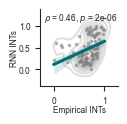

In [103]:
from src import plotting

font_size = 6
plt.rcParams.update({
        'font.size': font_size,
        'axes.labelsize': font_size,
        'axes.titlesize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'figure.titlesize': font_size+2
    })

y_data = plotting_df[plotting_df.kernel=='Masked S-A']['y'].to_numpy()
x_data = fmri_ac_df['acw_0'].to_numpy()
if True:
    x_data = (x_data-np.min(x_data))/(np.max(x_data)-np.min(x_data))
    y_data = (y_data-np.min(y_data))/(np.max(y_data)-np.min(y_data))

# slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
# spearman_r, spearman_p = stats.spearmanr(x_data, y_data)
# line_x = np.array([min(x_data), max(x_data)])
# line_y = slope * line_x + intercept

f = plt.figure(figsize=(1,1))
ax = plt.gca()
# plt.scatter(x=x_data, y=y_data, s=50,
#             c=[.7,.7,.7], edgecolors='black',
#             alpha=0.5)
# plt.plot(line_x, line_y,
#          color='black', linewidth=2)

# ax.set_xlabel('Empirical (fMRI)')
# ax.set_ylabel('bioRNN')
# plt.show()

plotting.my_reg_plot(x=x_data, y=y_data,
                     xlabel='Empirical INTs', ylabel='RNN INTs',
                     annotate='spearman',
                     fontsize=font_size,
                     ax=ax)

f.savefig('/users/ahmad/Dropbox/Rutgers/projects/neuro_rnn/OHBM2025/corrplot.svg', format='svg')
np.savetxt('/users/ahmad/Dropbox/Rutgers/projects/neuro_rnn/OHBM2025/corrplot_xdata_fmri.txt', x_data)
np.savetxt('/users/ahmad/Dropbox/Rutgers/projects/neuro_rnn/OHBM2025/corrplot_ydata_rnn.txt', y_data)



### Correlation of ACW and ACA with SA axis.

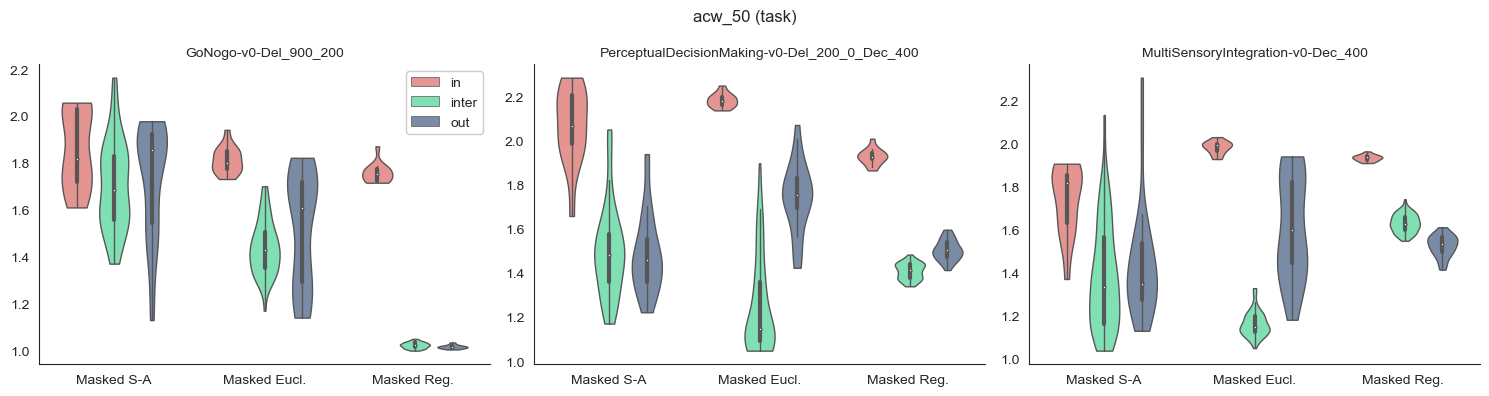

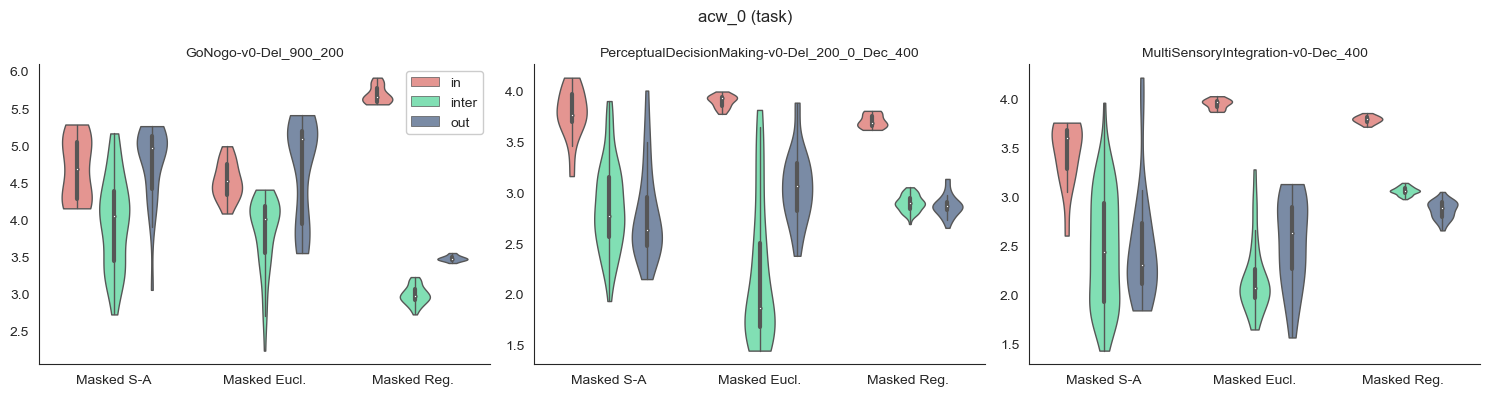

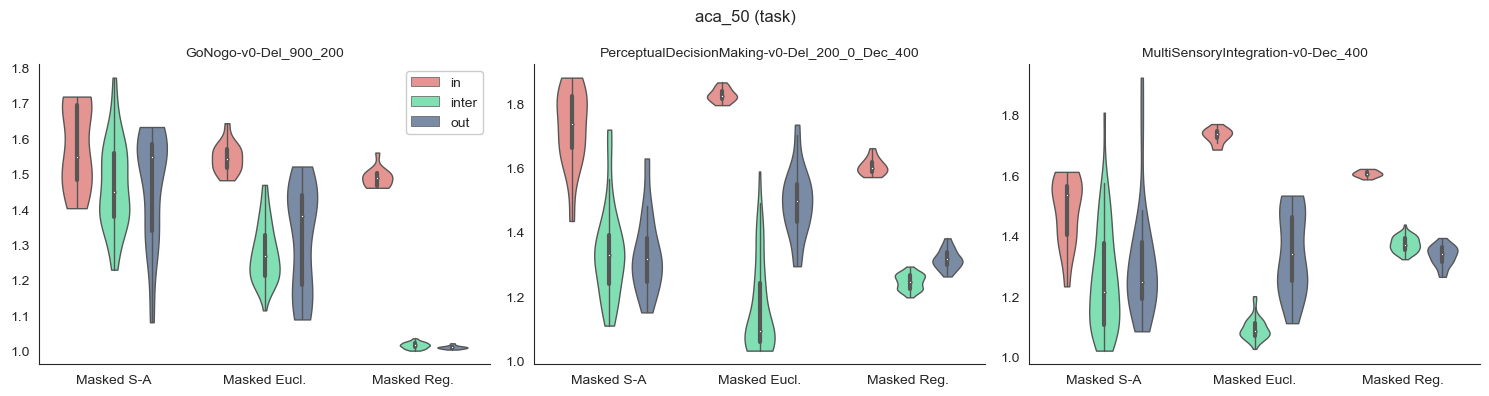

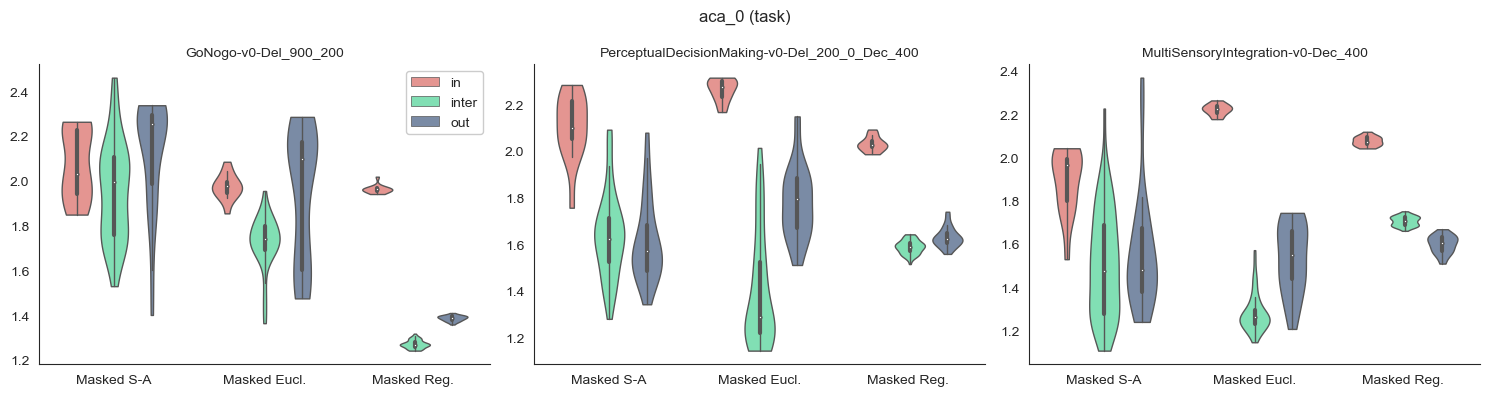

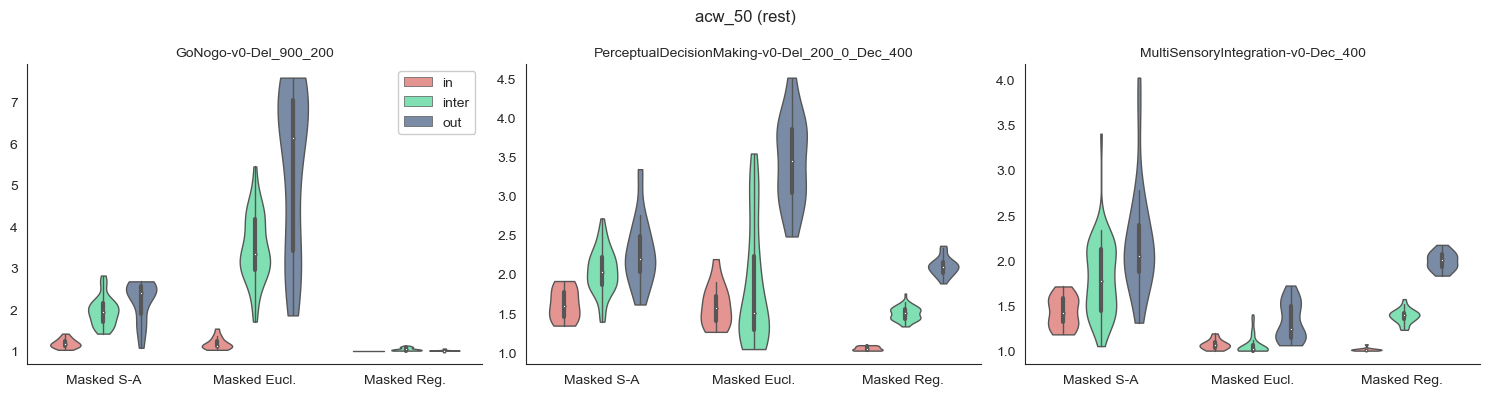

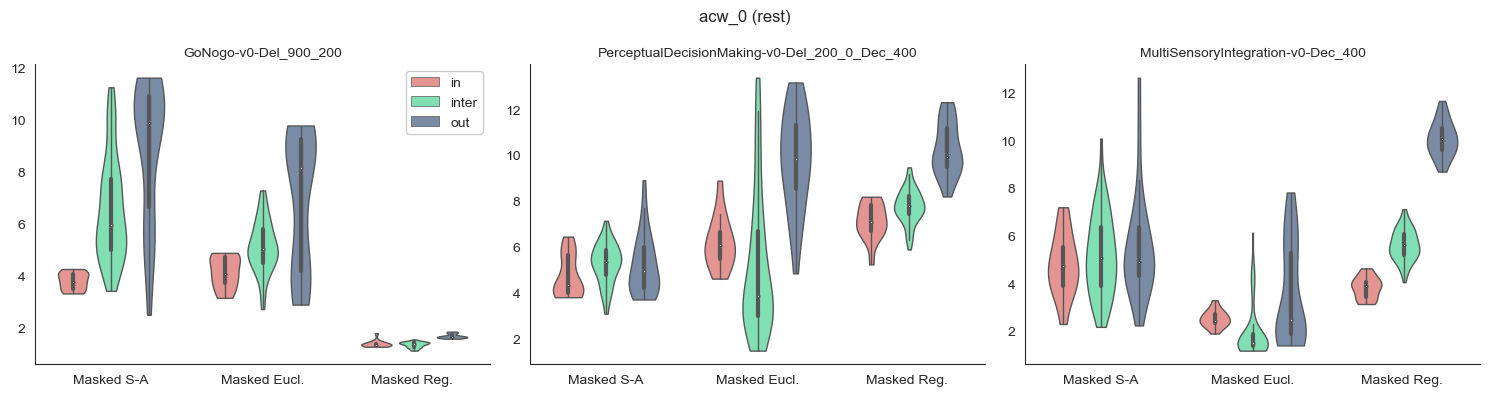

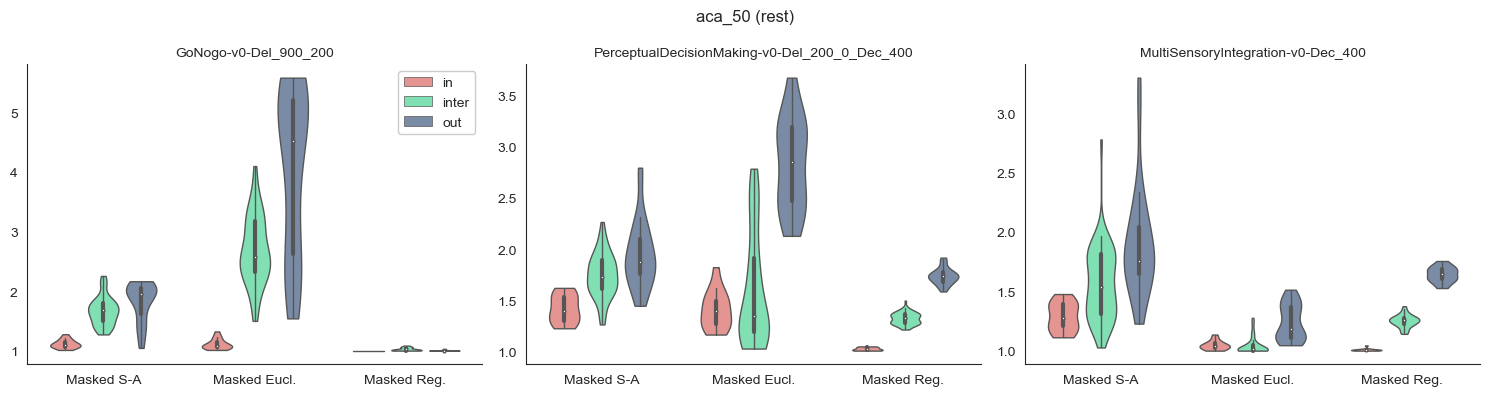

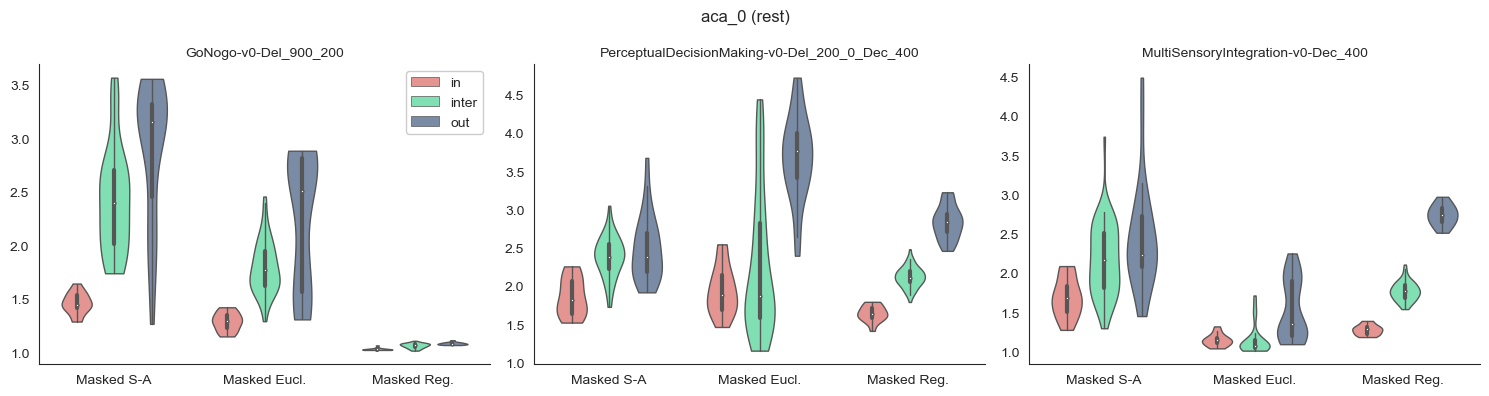

In [13]:
# re-organize data for easier handling
plotting_data = [
    [ac_data_task, 'task'],
    [ac_data_rest, 'rest']
]
plotting_keys = [
    'acw_50',
    'acw_0',
    'aca_50',
    'aca_0'
]

# figure params
size_scale = 2
font_size = int(5 * size_scale)
n_fig_columns = min((5, n_tasks))
n_fig_rows = math.ceil( n_tasks / n_fig_columns )
fig_size_w = 2.5*n_fig_columns*size_scale
fig_size_h = 2*n_fig_rows*size_scale

# we will create separate figures for task data and rest data,
# and for each of acw_50, acw_0, aca_50, aca_0
for i in range(len(plotting_data)):
    
    for j in range(len(plotting_keys)):

        # for the ACW and ACA plots, we will create one subplot per task
        # each subplot will contain scatter plots for the three kernels
        
        # create subplots
        f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                               squeeze=True, sharex=True, sharey=False)
        plt.rcParams.update({
            'font.size': font_size,
            'axes.labelsize': font_size,
            'axes.titlesize': font_size,
            'xtick.labelsize': font_size,
            'ytick.labelsize': font_size,
            'legend.fontsize': font_size,
            'figure.titlesize': font_size+2
        })

        
        # tasks loop
        for task_index in range(n_tasks):
            
            # get data for this task
            this_task_models = model_params[model_params['task_index']==task_index] # df of selected models
            
            # initialize dataframe for violin plots
            plotting_df = pd.DataFrame()
            
            for model_idx in range(len(this_task_models)):
                
                # get data for this model
                this_model_data = plotting_data[i][0][this_task_models.iloc[model_idx].model_index] # list of runs
                this_model_kernel = this_task_models.iloc[model_idx].kernel_label
                this_model_task = this_task_models.iloc[model_idx].task_label
                
                # initialize y values array
                y_plot = np.zeros((n_nodes,len(this_model_data))) 
                
                # populate array with mean across trials for each node and each run
                for run in range(n_runs):
                    run_data = this_model_data[run][plotting_keys[j]]
                    if run_data.ndim == 2:
                        y_plot[:,run] = run_data.mean(axis=1) # mean across task trials 
                    else:
                        y_plot[:,run] = run_data # values from rest 
                
                # calculate mean across runs
                y_plot = np.squeeze(y_plot.mean(axis=1))
                
                # add this model's data to the df
                this_plotting_df = pd.DataFrame({'y': y_plot, 
                                                 'task': this_model_task,
                                                 'kernel': np.repeat(this_model_kernel,(n_nodes)), 
                                                 'node_group': node_groups_labels})
                plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)
                
            # add padding between kernels in df
            plotting_df['x_labels'] = plotting_df['kernel'] + ' -- ' + plotting_df['node_group']
            kernels = plotting_df.kernel.unique()
            plotting_df_with_space = pd.DataFrame()
            # violin_order = []
            for ki, k in enumerate(kernels):
                plotting_df_with_space = pd.concat([
                    plotting_df_with_space, 
                    plotting_df[plotting_df['kernel'] == k]
                ])
                # violin_order.append(k)
                if ki < len(kernels)-1:
                    plotting_df_with_space = pd.concat([
                        plotting_df_with_space, 
                        pd.DataFrame({'x_labels': [''], 'y': [None]})
                    ])
                    # violin_order.append('')
            plotting_df = plotting_df_with_space
            
            # get plotting order 
            mask = (plotting_df['x_labels'] != plotting_df['x_labels'].shift())
            violin_order = plotting_df.loc[mask, 'x_labels']
            # violin_order = [v if isinstance(v,str) else '' for v in plotting_df.loc[mask, 'kernel'].tolist()]
            hue_order = plotting_df.node_group.unique()[:-1].astype(str)
            palette = dict(zip(hue_order,np.flip(colors_categ,axis=0)))
            
            # plot
            plot_type = 'violin' # violin or swarm
            if plot_type == 'violin':
                sns.violinplot(x='x_labels', y='y', hue='node_group', data=plotting_df,
                            linewidth=1, cut=0, saturation=1, inner='box', dodge=False, 
                            palette=palette, order=violin_order, hue_order=hue_order,
                            ax=f_ac.axes[task_index])
            elif plot_type == 'swarm':
                sns.swarmplot(x='x_labels', y='y', hue='node_group', data=plotting_df,
                            linewidth=1, dodge=False, 
                            palette=palette, order=violin_order, hue_order=hue_order,
                            ax=f_ac.axes[task_index])
            xlims = (-1,len(violin_order))

            # polish plots
            ax = f_ac.axes[task_index]
            xticks = np.where(violin_order!='')[0]
            xticks = xticks[np.arange(1,len(xticks),3)]
            ax.set_xticks(xticks,labels=kernels)
            ax.set_xlim(xlims)
            ax.set_xlabel('')
            # ax.set_ylabel(plotting_keys[j])
            ax.set_ylabel('')
            if task_index == 0:
                ax.legend(ncol=1, framealpha=1.0)
            else:
                ax.get_legend().remove()
            ax.set_title(task_names[task_index])
            f_ac.suptitle(plotting_keys[j] + ' (' + plotting_data[i][1] + ')')
            sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_ac.tight_layout()

# Functional Connectivity

Compute FC between RNN nodes and examine the effect of kernel distance on edge weights. Do this for SA axis and Euclidean and compare the pair.

In [ ]:
plt.figure(figsize=(20,10))
x = test_data_rest[10][0]['hidden_activity'][:100,:]
for i in np.arange(0,x.shape[1]):
    plt.plot(x[:,i], color=colors[i,:])
plt.legend()
plt.show()

In [ ]:
fc_vals_all = []
fc_vals_rest_all = []
for model_idx in tqdm(range(n_models),desc='Calculating FC (task & rest)'):
    fc_vals = np.zeros((n_nodes,n_nodes,n_runs))
    fc_vals_rest = np.zeros((n_nodes,n_nodes,n_runs))
    for run in range(n_runs):
        activity = test_data_task[model_idx][run]['hidden_activity']
        ts_len = (activity[0].shape[0]) * n_trials # length of the entire time series
        # create a [nodes x ts_len] array of activity for this run
        ts = np.zeros((n_nodes,ts_len))
        for node in range(n_nodes):
            # get data from the first trial
            ts_node = activity[0][:,node] 
            for trial in np.arange(1,n_trials):
                # append data from each subsequent trial
                ts_node = np.concatenate((ts_node, activity[trial][:,node]))
            ts[node,:] = ts_node
        ts_rest = test_data_rest[model_idx][run]['hidden_activity'].T
        # compute FC for this run
        fc = 1 - distance.squareform(distance.pdist(ts, 'correlation'))
        fc_vals[:,:,run] = fc
        fc = 1 - distance.squareform(distance.pdist(ts_rest, 'correlation'))
        fc_vals_rest[:,:,run] = fc
    fc_mean = fc_vals.mean(axis=2)
    fc_mean_rest = fc_vals_rest.mean(axis=2)
    fc_vals_all.append(fc_mean) 
    fc_vals_rest_all.append(fc_mean_rest) 


In [ ]:
model_idx = 11
kernel_str = model_params.iloc[model_idx].kernel_label
smooth_str = ' smoothing = ' + str(smooth_noise)

x = fc_vals_all[model_idx]
plt.figure()
sns.heatmap(x, cbar=1, center=0, cmap='coolwarm', mask=np.eye(n_nodes).astype(bool))
plt.title(f'FC task [{kernel_str}]')
plt.show()

x = fc_vals_rest_all[model_idx]
plt.figure()
sns.heatmap(x, cbar=1, center=0, cmap='coolwarm', mask=np.eye(n_nodes).astype(bool))
plt.title(f'FC rest [{kernel_str}], {smooth_str}')
plt.show()


# Task variability

Inspired by Robert Yang's "task variability" measure, examine the time to peak variability of RNN time series. Again, this will create brain maps. We will compare these brain maps between RNN models, but can't compare against empirical.